In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [16]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100.0%
100.0%


In [17]:
perm = torch.randperm(28 * 28)

def shuffle_image(img):
    img = img.view(-1)
    img = img[perm]
    return img.view(1,28,28)

In [18]:
class ShuffledMNIST(torch.utils.data.Dataset):

    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        image = shuffle_image(image)
        return image, label

In [19]:
batch_size = 64

train_loader = DataLoader(train_dataset,
                          batch_size=batch_size,
                          shuffle=True)

test_loader = DataLoader(test_dataset,
                        batch_size=batch_size)

train_shuffle_loader = DataLoader(
    ShuffledMNIST(train_dataset),
    batch_size=batch_size,
    shuffle=True
)

test_shuffle_loader = DataLoader(
    ShuffledMNIST(test_dataset),
    batch_size=batch_size
)

In [20]:
class MLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(

            nn.Flatten(),

            nn.Linear(784,512),
            nn.ReLU(),

            nn.Linear(512,256),
            nn.ReLU(),

            nn.Linear(256,10)
        )

    def forward(self,x):
        return self.network(x)

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_model(train_loader, test_loader, epochs=5):

    model = MLP().to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    test_acc = []

    for epoch in range(epochs):

        model.train()

        running_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        train_losses.append(running_loss / len(train_loader))

        model.eval()

        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in test_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                _, predicted = outputs.max(1)

                total += labels.size(0)

                correct += predicted.eq(labels).sum().item()

        accuracy = 100 * correct / total

        test_acc.append(accuracy)

        print(
            f"Epoch {epoch+1}: "
            f"Loss={train_losses[-1]:.4f} "
            f"Accuracy={accuracy:.2f}%"
        )

    return model, train_losses, test_acc

In [22]:
print("Training on Original MNIST")

model_original, loss_original, acc_original = train_model(
    train_loader,
    test_loader
)

Training on Original MNIST
Epoch 1: Loss=0.2368 Accuracy=96.55%
Epoch 2: Loss=0.0896 Accuracy=97.01%
Epoch 3: Loss=0.0575 Accuracy=97.74%
Epoch 4: Loss=0.0438 Accuracy=97.66%
Epoch 5: Loss=0.0314 Accuracy=97.54%


In [23]:
print("Training on Pixel-Shuffled MNIST")

model_shuffle, loss_shuffle, acc_shuffle = train_model(
    train_shuffle_loader,
    test_shuffle_loader
)

Training on Pixel-Shuffled MNIST
Epoch 1: Loss=0.2356 Accuracy=96.49%
Epoch 2: Loss=0.0892 Accuracy=97.19%
Epoch 3: Loss=0.0584 Accuracy=98.00%
Epoch 4: Loss=0.0431 Accuracy=97.67%
Epoch 5: Loss=0.0327 Accuracy=98.05%


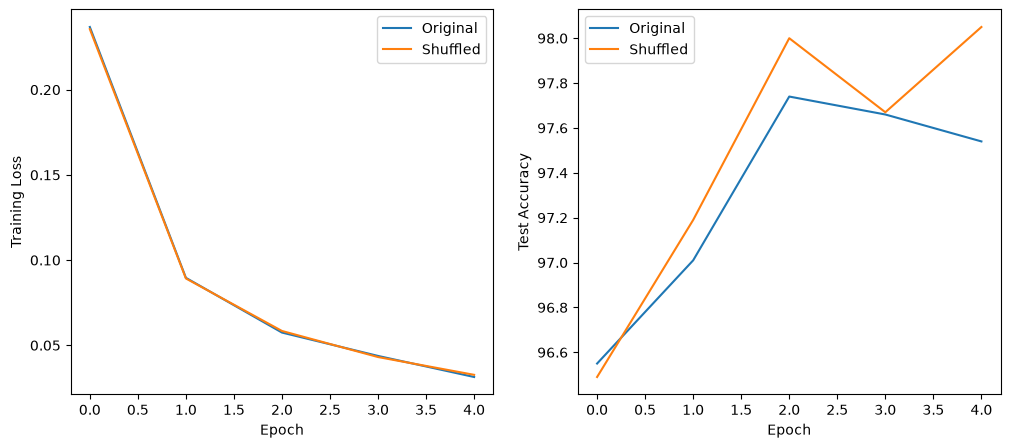

In [24]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(loss_original,label="Original")
plt.plot(loss_shuffle,label="Shuffled")

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend()

plt.subplot(1,2,2)

plt.plot(acc_original,label="Original")
plt.plot(acc_shuffle,label="Shuffled")

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")

plt.legend()

plt.show()

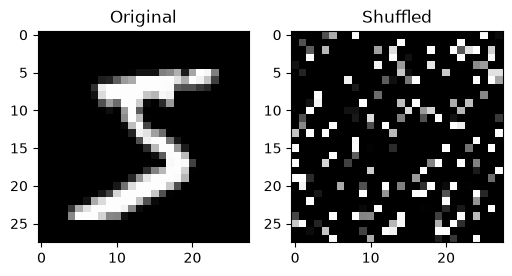

In [25]:
image, label = train_dataset[0]

shuffled = shuffle_image(image)

plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(image.squeeze(), cmap="gray")
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(shuffled.squeeze(), cmap="gray")
plt.title("Shuffled")

plt.show()